In [1]:
from pathlib import Path
import pandas as pd

src = Path("/home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/grouped_by_candidate_final_test_with_inferred_questions.csv")
dst = Path("/home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/grouped_by_candidate_final_test_with_inferred_questions_formatted.csv")

df = pd.read_csv(src)

# Fix typo column if present
if "questino_part3" in df.columns and "question_part3" not in df.columns:
    df = df.rename(columns={"questino_part3": "question_part3"})

# Build Question list column
def build_question(row):
    parts = [
        row.get("question_part1", ""),
        row.get("question_part2", ""),
        row.get("question_part3", ""),
    ]
    return parts

df["Question"] = df.apply(build_question, axis=1)

# Keep columns in the same order as test_split_with_questions.csv
target_cols = [
    "Candidate_ID",
    "absolute_paths",
    "question_code",
    "fluency",
    "pronunciation",
    "grammar",
    "vocabulary",
    "content",
    "final",
    "text",
    "question_type",
    "num_samples",
    "Question",
]

df_out = df[target_cols]

df_out.to_csv(dst, index=False)
print(f"Saved: {dst}")


Saved: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/grouped_by_candidate_final_test_with_inferred_questions_formatted.csv


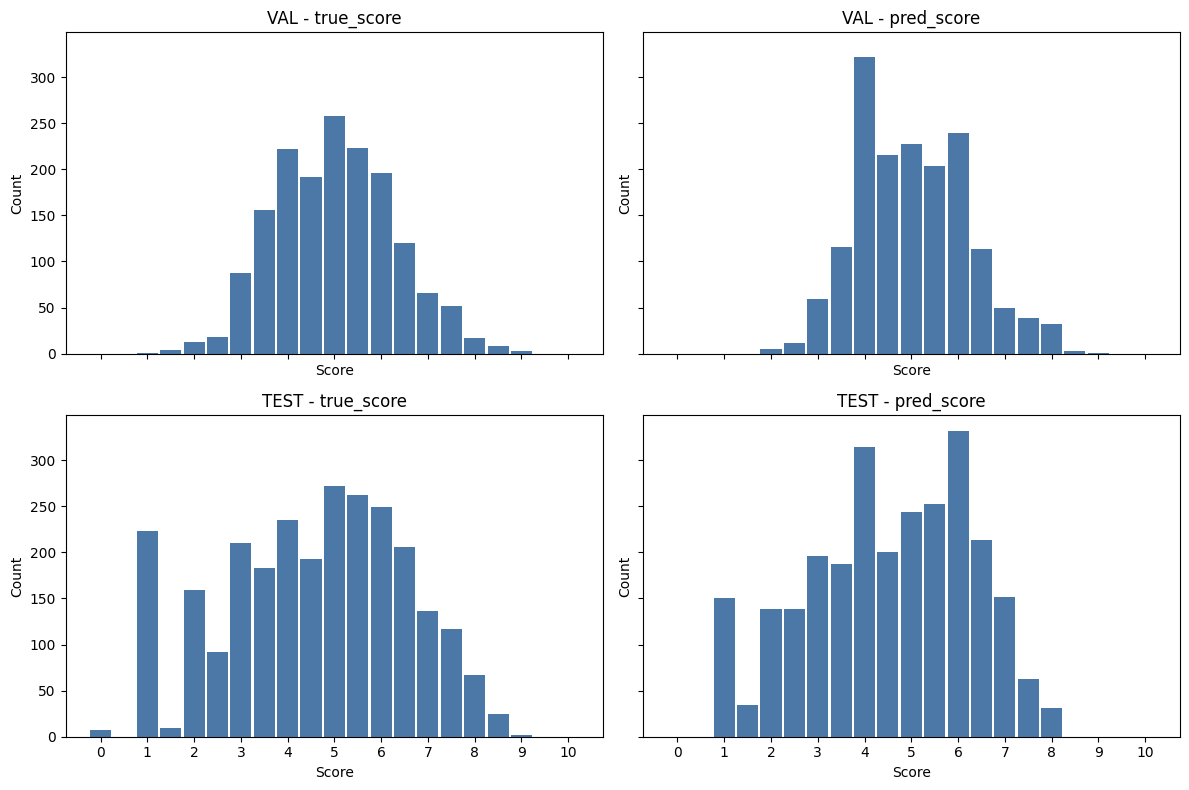

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = Path('/home/user06/Interspeech_2026/Model/Model/preds')
splits = {
    'val': pd.read_csv(base / 'val_predictions.csv'),
    'test': pd.read_csv(base / 'test_predictions.csv'),
}

bins = np.arange(0.0, 10.5, 0.5)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for row, (name, df) in enumerate(splits.items()):
    for col, score_col in enumerate(["true_score", "pred_score"]):
        ax = axes[row, col]
        vals = (df[score_col] * 2).round() / 2
        counts = vals.value_counts().reindex(bins, fill_value=0).sort_index()
        ax.bar(bins, counts.values, width=0.45, color="#4C78A8")
        ax.set_title(f"{name.upper()} - {score_col}")
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
        ax.set_xticks(np.arange(0, 10.5, 1.0))

plt.tight_layout()
plt.show()



=== TRAIN ===
MAE 0.0882, MSE 0.0621, RMSE 0.2492, QWK 0.9896
edge_mae 0.1239, mid_mae 0.0269
edge_pred_ratio 0.6270, edge_true_ratio 0.6322
%|err|<=0.5: 99.13%, %|err|<=1.0: 99.76%,  %|err|>1.0: 0.24%,  %|err|>1.5: 0.17%


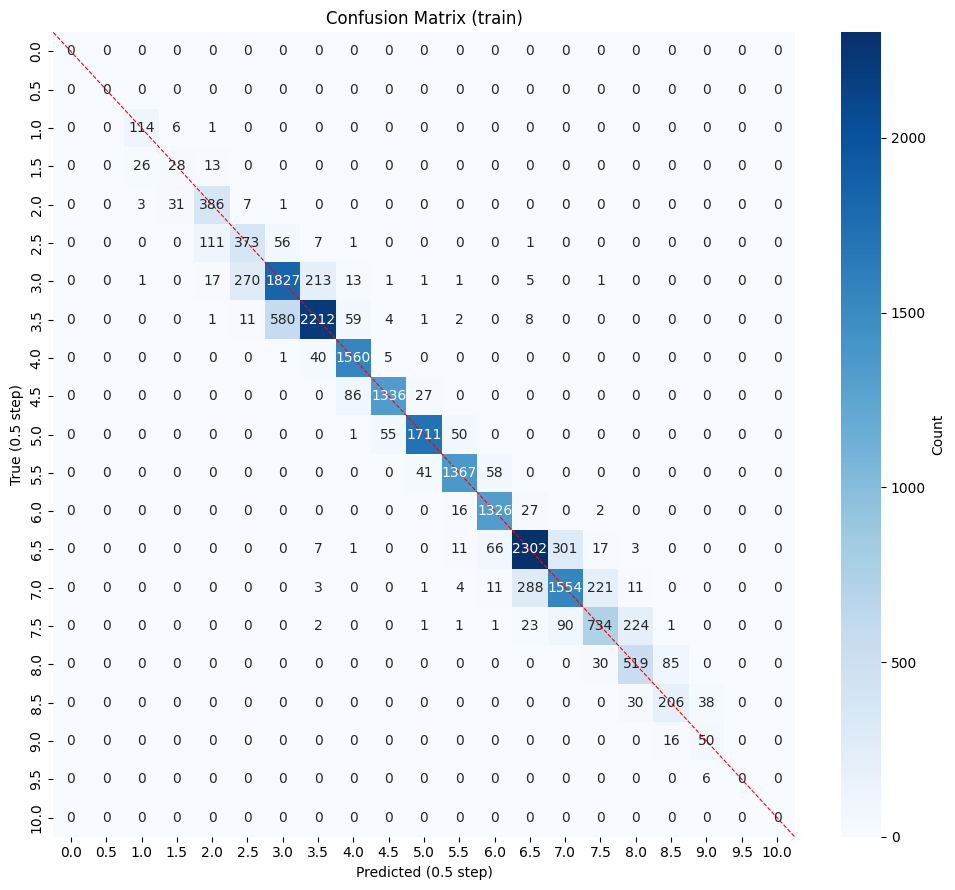


=== VAL ===
MAE 0.5473, MSE 0.5480, RMSE 0.7402, QWK 0.8205
edge_mae 0.5504, mid_mae 0.5458
edge_pred_ratio 0.2627, edge_true_ratio 0.3335
%|err|<=0.5: 72.21%, %|err|<=1.0: 91.75%,  %|err|>1.0: 8.25%,  %|err|>1.5: 2.38%


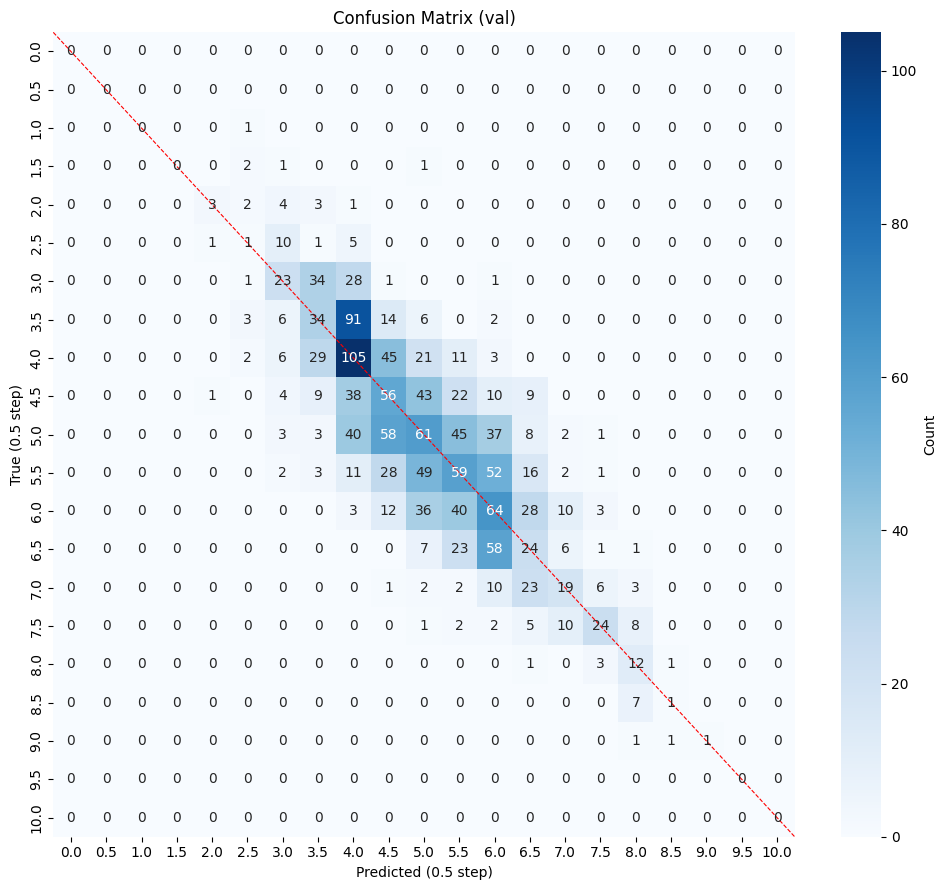


=== TEST ===
MAE 0.6900, MSE 0.8793, RMSE 0.9377, QWK 0.8694
edge_mae 0.7169, mid_mae 0.6581
edge_pred_ratio 0.4917, edge_true_ratio 0.5413
%|err|<=0.5: 61.10%, %|err|<=1.0: 83.30%,  %|err|>1.0: 16.70%,  %|err|>1.5: 5.87%


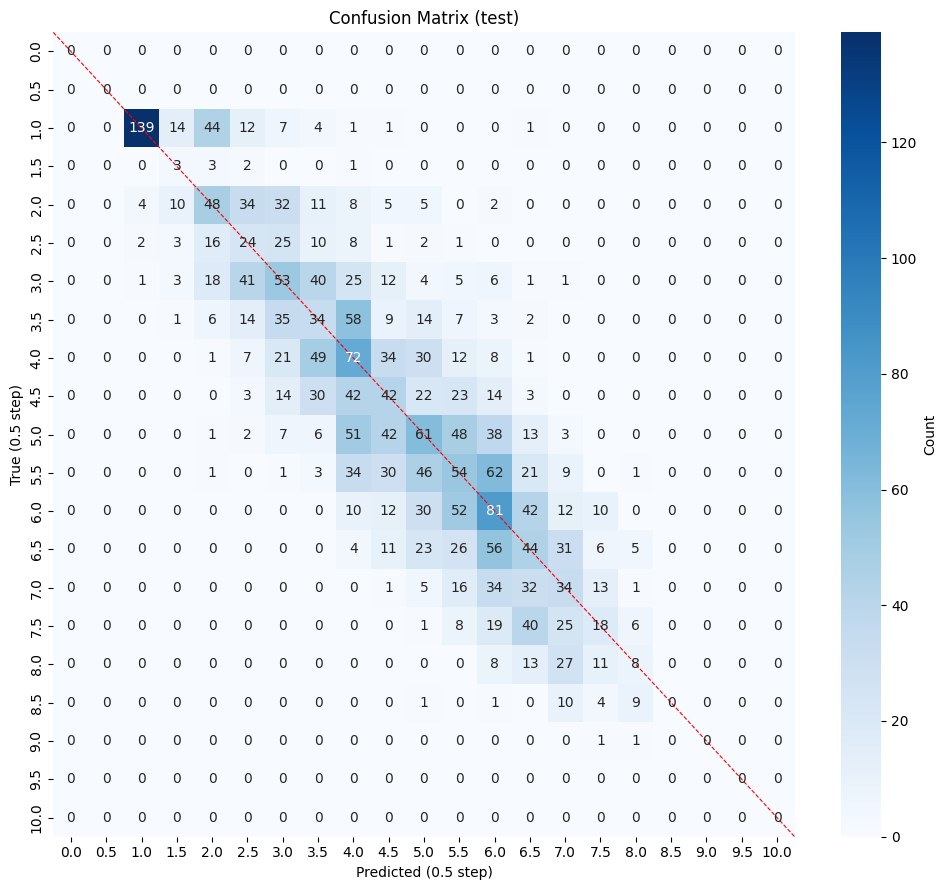

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from pathlib import Path

base = Path('/home/user06/Interspeech_2026/Model/Model/preds')
splits = {
    'train': pd.read_csv(base / 'train_predictions.csv'),
    'val': pd.read_csv(base / 'val_predictions.csv'),
    'test': pd.read_csv(base / 'test_predictions.csv'),
}

edge_thr = 3.5
labels_int = np.arange(0, 21)         # 0..20 bins (0.5 step)
score_ticks = np.arange(0, 10.5, 0.5) # for axis labels

for name, df in splits.items():
    print(f"\n=== {name.upper()} ===")
    # chỉ lấy các điểm > 0.5
    df = df[df['true_score'] > 0.5]
    y_true = df['true_score'].to_numpy()
    y_true = np.round(y_true * 2 ) / 2.0
    y_pred = df['pred_score'].to_numpy()
    y_pred = np.round(y_pred * 2) / 2.0
    err = y_pred - y_true
    abs_err = np.abs(err)

    # Metrics
    mae = np.mean(abs_err)
    mse = np.mean(err**2)
    rmse = np.sqrt(mse)
    qwk = cohen_kappa_score(np.round(y_true*2).astype(int),
                            np.round(y_pred*2).astype(int),
                            weights='quadratic')
    edge_mask = (y_true <= edge_thr) | (y_true >= (10 - edge_thr))
    mid_mask = ~edge_mask
    edge_mae = np.mean(abs_err[edge_mask]) if edge_mask.any() else np.nan
    mid_mae = np.mean(abs_err[mid_mask]) if mid_mask.any() else np.nan
    edge_pred_ratio = ((y_pred <= edge_thr) | (y_pred >= (10 - edge_thr))).mean()
    edge_true_ratio = edge_mask.mean()

    pct_le_0_5 = (abs_err <= 0.5).mean()*100
    pct_le_1_0 = (abs_err <= 1.0).mean()*100
    pct_gt_1_0 = (abs_err > 1.0).mean()*100
    pct_gt_1_5 = (abs_err > 1.5).mean()*100
    

    print(f"MAE {mae:.4f}, MSE {mse:.4f}, RMSE {rmse:.4f}, QWK {qwk:.4f}")
    print(f"edge_mae {edge_mae:.4f}, mid_mae {mid_mae:.4f}")
    print(f"edge_pred_ratio {edge_pred_ratio:.4f}, edge_true_ratio {edge_true_ratio:.4f}")
    print(f"%|err|<=0.5: {pct_le_0_5:.2f}%, %|err|<=1.0: {pct_le_1_0:.2f}%,  %|err|>1.0: {pct_gt_1_0:.2f}%,  %|err|>1.5: {pct_gt_1_5:.2f}%")

    # Binning to 0.5 and int labels
    true_bins = np.round(y_true * 2) / 2.0
    pred_bins = np.round(y_pred * 2) / 2.0
    true_lbl = np.round(true_bins * 2).astype(int)
    pred_lbl = np.round(pred_bins * 2).astype(int)

    cm = confusion_matrix(true_lbl, pred_lbl, labels=labels_int)

    plt.figure(figsize=(10, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=score_ticks, yticklabels=score_ticks, cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted (0.5 step)')
    plt.ylabel('True (0.5 step)')
    plt.title(f'Confusion Matrix ({name})')
    plt.plot([0, len(labels_int)], [0, len(labels_int)], color='red', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()


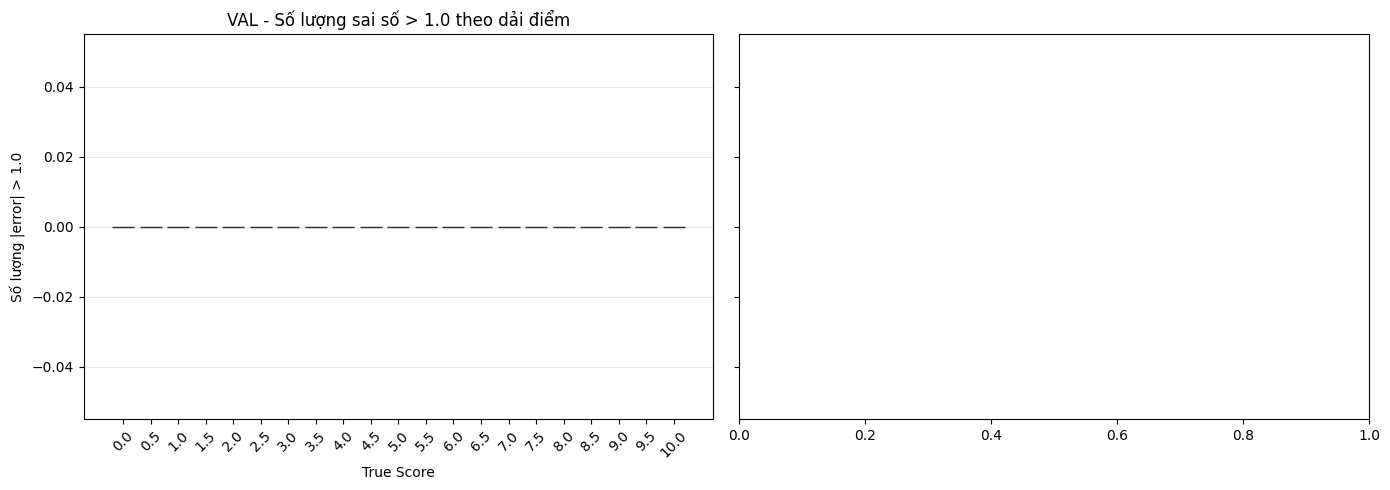


=== VAL ===
Score    Total    |err|>1    %       
------------------------------------
0.0      53       0          0.0     
0.5      10       0          0.0     
1.0      256      0          0.0     
1.5      128      0          0.0     
2.0      840      0          0.0     
2.5      1009     0          0.0     
3.0      4299     0          0.0     
3.5      5230     0          0.0     
4.0      6398     0          0.0     
4.5      5414     0          0.0     
5.0      6557     0          0.0     
5.5      5077     0          0.0     
6.0      5261     0          0.0     
6.5      4922     0          0.0     
7.0      3773     0          0.0     
7.5      1938     0          0.0     
8.0      1215     0          0.0     
8.5      504      0          0.0     
9.0      148      0          0.0     
9.5      12       0          0.0     
10.0     2        0          0.0     


In [29]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = Path('/home/user06/Interspeech_2026/Model/Model/preds')
splits = {
    #'val': pd.read_csv(base / 'val_predictions.csv'),
    'val': pd.read_csv('/home/user06/data/Speaking_VSTEP/Test_V2/with_instruction/unseen/train_full_3dot.csv'),
    #'test': pd.read_csv(base / 'test_predictions.csv'),
}

# Định nghĩa các dải điểm (0.5 step)
score_bins = np.arange(0, 10.5, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (name, df) in zip(axes, splits.items()):
    y_true = df['final'].to_numpy()
    y_true = np.round(y_true * 2) / 2.0
    y_pred = df['final'].to_numpy()
    y_pred = np.round(y_pred * 2) / 2.0
    abs_err = np.abs(y_pred - y_true)
    
    # Làm tròn true_score về bước 0.5
    true_bins = np.round(y_true * 2) / 2.0
    
    # Đếm số lượng sai số > 1 trên từng dải điểm
    error_counts = []
    for score in score_bins:
        mask = (true_bins == score) & (abs_err > 1.0)
        error_counts.append(mask.sum())
    
    # Vẽ biểu đồ cột
    bars = ax.bar(score_bins, error_counts, width=0.4, color='#E45756', edgecolor='black')
    
    # Thêm số liệu trên mỗi cột
    for bar, count in zip(bars, error_counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    str(count), ha='center', va='bottom', fontsize=8)
    
    ax.set_title(f'{name.upper()} - Số lượng sai số > 1.0 theo dải điểm')
    ax.set_xlabel('True Score')
    ax.set_ylabel('Số lượng |error| > 1.0')
    ax.set_xticks(score_bins)
    ax.set_xticklabels([f'{s:.1f}' for s in score_bins], rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# In thống kê chi tiết
for name, df in splits.items():
    print(f"\n=== {name.upper()} ===")
    y_true = df['final'].to_numpy()
    y_pred = df['final'].to_numpy()
    abs_err = np.abs(y_pred - y_true)
    true_bins = np.round(y_true * 2) / 2.0
    
    print(f"{'Score':<8} {'Total':<8} {'|err|>1':<10} {'%':<8}")
    print("-" * 36)
    for score in score_bins:
        total = (true_bins == score).sum()
        err_gt_1 = ((true_bins == score) & (abs_err > 1.0)).sum()
        pct = (err_gt_1 / total * 100) if total > 0 else 0
        if total > 0:
            print(f"{score:<8.1f} {total:<8} {err_gt_1:<10} {pct:<8.1f}")

In [5]:
# Filter out all samples with |error| > 1.0
for name, df in splits.items():
    y_true = df['true_score'].to_numpy()
    y_pred = df['pred_score'].to_numpy()
    abs_err = np.abs(y_pred - y_true)
    filtered_df = df[abs_err >= 1.0]
    print(f"{name.upper()} - Original samples: {len(df)}, After filtering: {len(filtered_df)}")

# Save filtered dataframes if needed
filtered_df.to_csv(base / f'{name}_filtered_err_gt_1.csv', index=False)

VAL - Original samples: 1637, After filtering: 248
TEST - Original samples: 2647, After filtering: 688


In [10]:
import pandas as pd
import random
import ast 
candidates_err_gt_1 = pd.read_csv('/home/user06/Interspeech_2026/Model/Model/preds/test_filtered_err_gt_1.csv')

test_df = pd.read_csv('/home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/grouped_by_candidate_final_test_with_inferred_questions.csv')

candidates_list = list(candidates_err_gt_1['Candidate_ID'])
rand_candidate = random.choice(candidates_list)
print(f"Random candidate with |error| > 1.0: {rand_candidate}")

# Get the audio paths and true/pred scores for this candidate
candidate_data = test_df[test_df['Candidate_ID'] == rand_candidate].iloc[0]
true_score, pred_score = candidates_err_gt_1[candidates_err_gt_1['Candidate_ID'] == rand_candidate][['true_score', 'pred_score']].values[0]
print(f"True Score: {true_score}, Predicted Score: {pred_score}")

# Load sample audio and listen
audio_paths = candidate_data['absolute_paths'] if isinstance(candidate_data['absolute_paths'], list) else ast.literal_eval(candidate_data['absolute_paths'])

audio_idx = 1
audio_path = audio_paths[audio_idx]
print(f"Listening to audio {audio_idx + 1}/{len(audio_paths)}: {audio_path}")
import IPython.display as ipd
ipd.Audio(audio_path)

Random candidate with |error| > 1.0: VCTEA0110250066
True Score: 8.5, Predicted Score: 6.792287
Listening to audio 2/3: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/1. BO 22 DE/UFM_22DE_DULIEUNOI/VCTEA24925Q7GL532/VCTEA0110250066-2.mp3


In [12]:
import numpy as np
import librosa
import soundfile as sf
from scipy import signal
from scipy.ndimage import uniform_filter1d
import noisereduce as nr
from pathlib import Path
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

class BreathingRemovalPipeline:
    """
    Hybrid pipeline for removing breathing sounds from audio recordings.
    Combines VAD, spectral analysis, and noise reduction.
    """
    
    def __init__(self, 
                 sample_rate: int = 16000,
                 vad_threshold: float = 0.5,
                 breath_freq_range: Tuple[float, float] = (100, 1000),
                 noise_reduce_strength: float = 0.7):
        """
        Initialize the pipeline.
        
        Args:
            sample_rate: Target sample rate for processing
            vad_threshold: Threshold for voice activity detection (0-1)
            breath_freq_range: Frequency range where breathing occurs (Hz)
            noise_reduce_strength: Strength of noise reduction (0-1)
        """
        self.sr = sample_rate
        self.vad_threshold = vad_threshold
        self.breath_freq_low, self.breath_freq_high = breath_freq_range
        self.noise_strength = noise_reduce_strength
        
    def process_batch(self, 
                      input_paths: List[str], 
                      output_paths: List[str]) -> Dict[str, any]:
        """
        Process a batch of audio files.
        
        Args:
            input_paths: List of input audio file paths
            output_paths: List of output audio file paths
            
        Returns:
            Dictionary with processing statistics
        """
        results = {
            'processed': 0,
            'failed': 0,
            'errors': []
        }
        
        for inp, outp in zip(input_paths, output_paths):
            try:
                print(f"Processing: {inp}")
                audio, sr = librosa.load(inp, sr=self.sr)
                processed = self.process_audio(audio)
                
                # Ensure output directory exists
                Path(outp).parent.mkdir(parents=True, exist_ok=True)
                sf.write(outp, processed, self.sr)
                
                results['processed'] += 1
                print(f"  ✓ Saved to: {outp}")
                
            except Exception as e:
                results['failed'] += 1
                results['errors'].append({'file': inp, 'error': str(e)})
                print(f"  ✗ Error: {str(e)}")
        
        return results
    
    def process_audio(self, audio: np.ndarray) -> np.ndarray:
        """
        Process a single audio array through the full pipeline.
        
        Args:
            audio: Audio signal as numpy array
            
        Returns:
            Processed audio signal
        """
        # Stage 1: Preprocessing - gentle high-pass filter
        audio_filtered = self._apply_highpass_filter(audio, cutoff=80)
        
        # Stage 2: Voice Activity Detection
        speech_segments = self._detect_speech_segments(audio_filtered)
        
        # Stage 3: Breathing Detection in non-speech segments
        breathing_segments = self._detect_breathing_segments(
            audio_filtered, speech_segments
        )
        
        # Stage 4: Extract noise profile from breathing segments
        noise_profile = self._extract_noise_profile(audio_filtered, breathing_segments)
        
        # Stage 5: Selective processing
        processed = self._selective_noise_reduction(
            audio_filtered, speech_segments, breathing_segments, noise_profile
        )
        
        # Stage 6: Smooth transitions
        processed = self._smooth_transitions(processed, speech_segments)
        
        return processed
    
    def _apply_highpass_filter(self, audio: np.ndarray, cutoff: float = 80) -> np.ndarray:
        """Apply a gentle high-pass filter to remove very low rumble."""
        nyquist = self.sr / 2
        normalized_cutoff = cutoff / nyquist
        b, a = signal.butter(4, normalized_cutoff, btype='high')
        return signal.filtfilt(b, a, audio)
    
    def _detect_speech_segments(self, audio: np.ndarray) -> List[Tuple[int, int]]:
        """
        Detect speech segments using energy-based VAD.
        
        Returns:
            List of (start, end) tuples in samples
        """
        # Calculate short-term energy
        frame_length = int(0.025 * self.sr)  # 25ms frames
        hop_length = int(0.010 * self.sr)    # 10ms hop
        
        # Compute RMS energy
        rms = librosa.feature.rms(y=audio, frame_length=frame_length, 
                                  hop_length=hop_length)[0]
        
        # Compute spectral centroid (speech has higher spectral centroid than breathing)
        spec_centroid = librosa.feature.spectral_centroid(
            y=audio, sr=self.sr, hop_length=hop_length
        )[0]
        
        # Normalize features
        rms_norm = (rms - np.min(rms)) / (np.max(rms) - np.min(rms) + 1e-8)
        cent_norm = (spec_centroid - np.min(spec_centroid)) / \
                    (np.max(spec_centroid) - np.min(spec_centroid) + 1e-8)
        
        # Combined metric (weighted)
        speech_prob = 0.6 * rms_norm + 0.4 * cent_norm
        
        # Smooth the probability
        speech_prob = uniform_filter1d(speech_prob, size=5)
        
        # Threshold to get binary speech/non-speech
        is_speech = speech_prob > self.vad_threshold
        
        # Convert to segments
        segments = []
        in_speech = False
        start = 0
        
        for i, val in enumerate(is_speech):
            if val and not in_speech:
                start = i * hop_length
                in_speech = True
            elif not val and in_speech:
                end = i * hop_length
                segments.append((start, end))
                in_speech = False
        
        # Handle case where speech continues to end
        if in_speech:
            segments.append((start, len(audio)))
        
        # Merge segments that are very close (< 200ms apart)
        merged = self._merge_close_segments(segments, min_gap=int(0.2 * self.sr))
        
        return merged
    
    def _merge_close_segments(self, segments: List[Tuple[int, int]], 
                             min_gap: int) -> List[Tuple[int, int]]:
        """Merge segments that are close together."""
        if not segments:
            return []
        
        merged = [segments[0]]
        for start, end in segments[1:]:
            last_end = merged[-1][1]
            if start - last_end < min_gap:
                # Merge with previous segment
                merged[-1] = (merged[-1][0], end)
            else:
                merged.append((start, end))
        
        return merged
    
    def _detect_breathing_segments(self, audio: np.ndarray, 
                                   speech_segments: List[Tuple[int, int]]) -> List[Tuple[int, int]]:
        """
        Detect breathing in non-speech segments based on spectral characteristics.
        """
        # Create mask for non-speech regions
        non_speech_mask = np.ones(len(audio), dtype=bool)
        for start, end in speech_segments:
            non_speech_mask[start:end] = False
        
        # Analyze non-speech segments for breathing characteristics
        frame_length = int(0.050 * self.sr)  # 50ms frames
        hop_length = int(0.025 * self.sr)    # 25ms hop
        
        # Get spectral content in breathing frequency range
        stft = librosa.stft(audio, n_fft=frame_length, hop_length=hop_length)
        freqs = librosa.fft_frequencies(sr=self.sr, n_fft=frame_length)
        
        # Find indices for breathing frequency range
        breath_idx = np.where((freqs >= self.breath_freq_low) & 
                             (freqs <= self.breath_freq_high))[0]
        
        # Energy in breathing range
        breath_energy = np.sum(np.abs(stft[breath_idx, :]), axis=0)
        total_energy = np.sum(np.abs(stft), axis=0)
        breath_ratio = breath_energy / (total_energy + 1e-8)
        
        # Breathing has high ratio of energy in low frequencies
        is_breathing = breath_ratio > 0.4
        
        # Convert frame-based detection to sample-based segments
        breathing_segments = []
        in_breathing = False
        start = 0
        
        for i, (is_breath, is_non_speech) in enumerate(
            zip(is_breathing, 
                [non_speech_mask[min(i * hop_length, len(non_speech_mask) - 1)] 
                 for i in range(len(is_breathing))])):
            
            sample_idx = i * hop_length
            
            if is_breath and is_non_speech and not in_breathing:
                start = sample_idx
                in_breathing = True
            elif (not is_breath or not is_non_speech) and in_breathing:
                end = sample_idx
                if end - start > int(0.1 * self.sr):  # Min 100ms duration
                    breathing_segments.append((start, end))
                in_breathing = False
        
        if in_breathing:
            breathing_segments.append((start, len(audio)))
        
        return breathing_segments
    
    def _extract_noise_profile(self, audio: np.ndarray, 
                               breathing_segments: List[Tuple[int, int]]) -> np.ndarray:
        """Extract noise profile from breathing segments."""
        if not breathing_segments:
            # If no breathing detected, use quiet segments
            return audio[:int(0.5 * self.sr)]  # First 0.5s as fallback
        
        # Collect all breathing samples
        breathing_samples = []
        for start, end in breathing_segments:
            breathing_samples.append(audio[start:end])
        
        if breathing_samples:
            return np.concatenate(breathing_samples)
        else:
            return audio[:int(0.5 * self.sr)]
    
    def _selective_noise_reduction(self, audio: np.ndarray,
                                   speech_segments: List[Tuple[int, int]],
                                   breathing_segments: List[Tuple[int, int]],
                                   noise_profile: np.ndarray) -> np.ndarray:
        """
        Apply selective noise reduction: light on speech, heavy on breathing.
        """
        processed = audio.copy()
        
        # Apply noise reduction to the entire audio with noise profile
        try:
            # Use the noise profile for reduction
            reduced = nr.reduce_noise(
                y=audio, 
                sr=self.sr,
                y_noise=noise_profile,
                prop_decrease=self.noise_strength,
                stationary=False
            )
        except:
            # Fallback if noise reduction fails
            reduced = audio
        
        # For speech segments, blend original with reduced (preserve more original)
        for start, end in speech_segments:
            # 80% original, 20% reduced for speech
            processed[start:end] = 0.8 * audio[start:end] + 0.2 * reduced[start:end]
        
        # For breathing segments, use heavily reduced version
        for start, end in breathing_segments:
            # Apply additional attenuation to breathing segments
            processed[start:end] = reduced[start:end] * 0.3
        
        # For other non-speech segments, use moderate reduction
        all_segments = set(range(len(audio)))
        speech_set = set()
        breathing_set = set()
        
        for start, end in speech_segments:
            speech_set.update(range(start, end))
        for start, end in breathing_segments:
            breathing_set.update(range(start, end))
        
        # This is simplified - in production, you'd want more efficient masking
        
        return processed
    
    def _smooth_transitions(self, audio: np.ndarray,
                           speech_segments: List[Tuple[int, int]]) -> np.ndarray:
        """Apply smooth crossfades at segment boundaries."""
        fade_length = int(0.02 * self.sr)  # 20ms fade
        
        processed = audio.copy()
        
        for start, end in speech_segments:
            # Fade in at start
            if start > 0:
                fade_start = max(0, start - fade_length // 2)
                fade_end = min(len(audio), start + fade_length // 2)
                fade_samples = fade_end - fade_start
                fade_curve = np.linspace(0, 1, fade_samples)
                processed[fade_start:fade_end] *= fade_curve
            
            # Fade out at end
            if end < len(audio):
                fade_start = max(0, end - fade_length // 2)
                fade_end = min(len(audio), end + fade_length // 2)
                fade_samples = fade_end - fade_start
                fade_curve = np.linspace(1, 0, fade_samples)
                processed[fade_start:fade_end] *= fade_curve
        
        return processed

/home/user06/miniconda3/envs/quangminh/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
denoise_processer = BreathingRemovalPipeline()
batch = [audio_path]
output_path = '/home/user06/Interspeech_2026/Model/Model/preds/denoised_audio.mp3'
denoise_processer.process_batch(batch, [output_path])
import IPython.display as ipd
ipd.Audio(output_path)

Processing: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/1. BO 22 DE/UFM_22DE_DULIEUNOI/VCTEA24925Q7GL532/VCTEA0110250066-2.mp3
  ✓ Saved to: /home/user06/Interspeech_2026/Model/Model/preds/denoised_audio.mp3


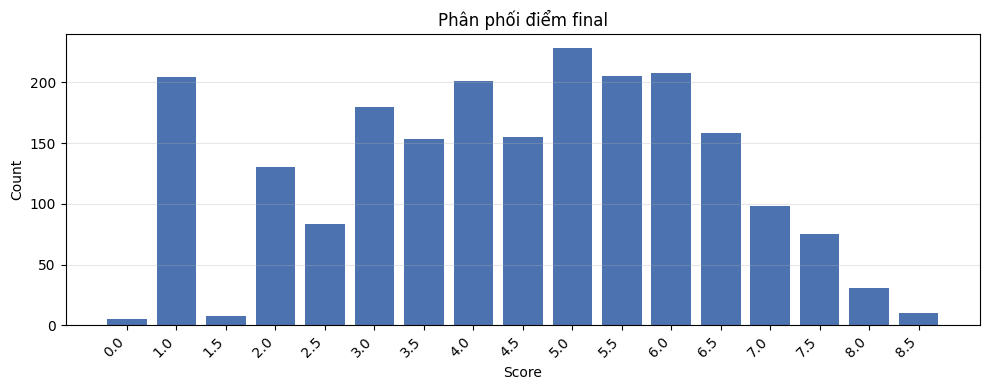

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#testpath = "/home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/grouped_by_candidate_final_test_with_inferred_questions_formatted.csv"
path = "/home/user06/Interspeech_2026/Model/Model/preds/test_filtered_err_le_1_0.csv"
df = pd.read_csv(path)

if "final" not in df.columns:
    raise ValueError(f"Không thấy cột 'final'. Các cột hiện có: {df.columns.tolist()}")

scores = pd.to_numeric(df["final"], errors="coerce")
counts = scores.value_counts(dropna=False).sort_index()

plt.figure(figsize=(10, 4))
plt.bar(counts.index.astype(str), counts.values, color="#4C72B0")
plt.title("Phân phối điểm final")
plt.xlabel("Score")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [1]:
import csv
import math
from pathlib import Path

pred_path = Path("/home/user06/Interspeech_2026/Model/Model/preds/test_predictions.csv")
data_path = Path("/home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/grouped_by_candidate_final_test_with_inferred_questions_formatted.csv")
out_path = Path("/home/user06/Interspeech_2026/Model/Model/preds/test_filtered_err_le_1_0.csv")

def round_half_up(x):
    return math.floor(x * 2) / 2.0

# Map Candidate_ID -> (pred_round, true_score)
pred_map = {}
with pred_path.open(newline='') as f:
    reader = csv.DictReader(f)
    for r in reader:
        cid = r.get("Candidate_ID")
        if not cid:
            continue
        try:
            true_score = float(r["true_score"])
            true_score = round_half_up(true_score)
            pred_score = float(r["pred_score"])
            pred_score = round_half_up(pred_score)
        except Exception:
            continue
        pred_round = round_half_up(pred_score)
        if abs(pred_round - true_score) <= 1.0:
            pred_map[cid] = (pred_round, abs(pred_round - true_score))

with data_path.open(newline='') as f_in, out_path.open('w', newline='') as f_out:
    reader = csv.DictReader(f_in)
    base_fields = reader.fieldnames
    if not base_fields:
        raise ValueError("No header in input data")

    # Insert pred_score + err_abs after final
    out_fields = []
    for col in base_fields:
        out_fields.append(col)
        if col == "final":
            out_fields.append("pred_score")
            out_fields.append("err_abs")

    writer = csv.DictWriter(f_out, fieldnames=out_fields)
    writer.writeheader()

    for row in reader:
        cid = row.get("Candidate_ID")
        if cid in pred_map:
            pred_round, err_abs = pred_map[cid]
            row["pred_score"] = pred_round
            row["err_abs"] = err_abs
            writer.writerow(row)

print("Saved:", out_path)


Saved: /home/user06/Interspeech_2026/Model/Model/preds/test_filtered_err_le_1_0.csv


In [7]:
import pandas as pd 
import ast
import os
err_gt_1_5 = pd.read_csv("/home/user06/Interspeech_2026/Model/Model/preds/test_filtered_err_gt_1_5.csv")
# Audio for problematic audio 
problem_audio_path = "/home/user06/Interspeech_2026/Model/Model/preds/problem_audio"
metadata = []
# Get the absolute paths of all samples with err > 1.5
abs_paths_by_cand = err_gt_1_5["absolute_paths"]
for abs_paths in abs_paths_by_cand:
    abs_paths_list = ast.literal_eval(abs_paths) if isinstance(abs_paths, str) else abs_paths
    for abs_path in abs_paths_list:
        if os.path.isfile(abs_path):
            filename = os.path.basename(abs_path)
            # Get the candidate ID 
            candidate_id = err_gt_1_5[err_gt_1_5["absolute_paths"] == abs_paths]["Candidate_ID"].values[0]
            if "BO 22 DE" in abs_path:
                dst_path = os.path.join(problem_audio_path, "BO 22 DE", candidate_id, filename)
                if not os.path.exists(os.path.join(problem_audio_path, "BO 22 DE", candidate_id)):
                    os.makedirs(os.path.join(problem_audio_path, "BO 22 DE", candidate_id))
            else:
                dst_path = os.path.join(problem_audio_path, "BO 18 DE", candidate_id, filename)
                if not os.path.exists(os.path.join(problem_audio_path, "BO 18 DE", candidate_id)):
                    os.makedirs(os.path.join(problem_audio_path, "BO 18 DE", candidate_id))
            # Copy the file to the destination
            os.system(f"cp '{abs_path}' '{dst_path}'")
            print(f"Copied: {abs_path} -> {dst_path}")

            # Create metadata for the audio file 
            metadata.append({
                "Candidate_ID": candidate_id,
                "audio_path": dst_path.replace("/home/user06/Interspeech_2026/Model/Model/preds/", ""),
            })

Copied: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/1. BO 22 DE/UFM_22DE_DULIEUNOI/VCTEA24925Q7GL531/VCTEA0110250005-1.mp3 -> /home/user06/Interspeech_2026/Model/Model/preds/problem_audio/BO 22 DE/VCTEA0110250005/VCTEA0110250005-1.mp3
Copied: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/1. BO 22 DE/UFM_22DE_DULIEUNOI/VCTEA24925Q7GL531/VCTEA0110250005-2.mp3 -> /home/user06/Interspeech_2026/Model/Model/preds/problem_audio/BO 22 DE/VCTEA0110250005/VCTEA0110250005-2.mp3
Copied: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/1. BO 22 DE/UFM_22DE_DULIEUNOI/VCTEA24925Q7GL531/VCTEA0110250005-3.mp3 -> /home/user06/Interspeech_2026/Model/Model/preds/problem_audio/BO 22 DE/VCTEA0110250005/VCTEA0110250005-3.mp3
Copied: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/1. BO 22 DE/UFM_22DE_DULIEUNOI/VCTEA24925Q7GL531/VCTEA0110250021-1.mp3 -> /home/user06/Interspeech_2026/Model/Model/preds/problem_audio/BO 22 DE/VCTEA0110250021/VC

Copied: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/1. BO 22 DE/UFM_22DE_DULIEUNOI/VCTEA24925Q7GL532/VCTEA0110250059-3.mp3 -> /home/user06/Interspeech_2026/Model/Model/preds/problem_audio/BO 22 DE/VCTEA0110250059/VCTEA0110250059-3.mp3
Copied: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/1. BO 22 DE/UFM_22DE_DULIEUNOI/VCTEA24925Q7GL532/VCTEA0110250064-1.mp3 -> /home/user06/Interspeech_2026/Model/Model/preds/problem_audio/BO 22 DE/VCTEA0110250064/VCTEA0110250064-1.mp3
Copied: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/1. BO 22 DE/UFM_22DE_DULIEUNOI/VCTEA24925Q7GL532/VCTEA0110250064-2.mp3 -> /home/user06/Interspeech_2026/Model/Model/preds/problem_audio/BO 22 DE/VCTEA0110250064/VCTEA0110250064-2.mp3
Copied: /home/user06/data/Speaking_VSTEP/20251219_DU_LIEU_AI_THU_NGHIEM/1. BO 22 DE/UFM_22DE_DULIEUNOI/VCTEA24925Q7GL532/VCTEA0110250064-3.mp3 -> /home/user06/Interspeech_2026/Model/Model/preds/problem_audio/BO 22 DE/VCTEA0110250064/VC

In [10]:
metadata_df = pd.DataFrame(metadata)
metadata_df.to_csv(os.path.join(problem_audio_path, "metadata.csv"), index=False)
print(f"Saved metadata to: {os.path.join(problem_audio_path, 'metadata.csv')}")

Saved metadata to: /home/user06/Interspeech_2026/Model/Model/preds/problem_audio/metadata.csv


In [4]:
print(len(err_gt_1_5))

198


In [3]:
from pathlib import Path

problem_audio_dir = Path(problem_audio_path)
mp3_files = list(problem_audio_dir.rglob("*.mp3"))

print(f"Found {len(mp3_files)} MP3 files:\n")
# for mp3_file in sorted(mp3_files):
#     print(mp3_file)

Found 583 MP3 files:

